In [15]:
import pandas as pd 

In [ ]:
# import pandas as pd 
df=pd.read_csv("data/career_roles.csv")
df=pd.read_csv("data/learning_resources.csv")
print(df.head(15))



                 role    required_skill  importance
0   Software Engineer            Python         1.0
1   Software Engineer               DSA         1.0
2   Software Engineer               OOP         0.9
3   Software Engineer              DBMS         0.8
4   Software Engineer               SQL         0.8
5   Software Engineer     System Design         0.8
6   Software Engineer               Git         0.7
7      Data Scientist            Python         1.0
8      Data Scientist            Pandas         1.0
9      Data Scientist             NumPy         1.0
10     Data Scientist  Machine Learning         1.0
11     Data Scientist      Scikit-learn         0.9
12     Data Scientist               SQL         0.8
13     Data Scientist          Power BI         0.7
14        ML Engineer            Python         1.0


In [6]:
import os
import pandas as pd

# -------------------------------
# Create processed folder
# -------------------------------
OUTPUT_FOLDER = "processed"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# -------------------------------
# CSV Files
# -------------------------------
files = [
    "Data/users.csv",
    "Data/skills.csv",
    "Data/user_skills.csv",
    "Data/career_roles.csv",
    "Data/learning_resources.csv",
    "Data/peer_data.csv"
]

# -------------------------------
# Cleaning Function
# -------------------------------
def clean_data(df):

    # Remove duplicate rows
    df = df.drop_duplicates()

    # Clean column names
    df.columns = df.columns.str.strip()

    # Remove spaces from string columns
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].str.strip()

    # Fill Missing Values
    for col in df.columns:

        if df[col].dtype == "object":

            if len(df[col].mode()) > 0:
                df[col] = df[col].fillna(df[col].mode()[0])
            else:
                df[col] = df[col].fillna("Unknown")

        else:
            df[col] = df[col].fillna(df[col].median())

    return df


# -------------------------------
# Process All Files
# -------------------------------
for file in files:

    print("=" * 60)
    print("Processing :", file)

    # Check file exists
    if not os.path.exists(file):
        print(f"{file} not found.")
        continue

    # Read CSV
    df = pd.read_csv(file)

    print("Original Shape :", df.shape)

    # Missing Values
    print("\nMissing Values")
    print(df.isnull().sum())

    # Duplicate Rows
    print("\nDuplicate Rows :", df.duplicated().sum())

    # Cleaning
    df = clean_data(df)

    print("\nAfter Cleaning Shape :", df.shape)

    print("Remaining Missing Values :", df.isnull().sum().sum())

    # Save
    # save_path = os.path.join(OUTPUT_FOLDER, file)
    save_path = os.path.join(OUTPUT_FOLDER, os.path.basename(file))

    df.to_csv(save_path, index=False)

    print("Saved Successfully ->", save_path)

print("\nAll datasets processed successfully.")

Processing : Data/users.csv
Original Shape : (500, 6)

Missing Values
user_id        0
name           0
college        0
branch         0
year           0
target_role    0
dtype: int64

Duplicate Rows : 0

After Cleaning Shape : (500, 6)
Remaining Missing Values : 0
Saved Successfully -> processed\users.csv
Processing : Data/skills.csv
Original Shape : (50, 3)

Missing Values
skill_id      0
skill_name    0
category      0
dtype: int64

Duplicate Rows : 0

After Cleaning Shape : (50, 3)
Remaining Missing Values : 0
Saved Successfully -> processed\skills.csv
Processing : Data/user_skills.csv
Original Shape : (3814, 3)

Missing Values
user_id    0
skill      0
level      0
dtype: int64

Duplicate Rows : 0

After Cleaning Shape : (3814, 3)
Remaining Missing Values : 0
Saved Successfully -> processed\user_skills.csv
Processing : Data/career_roles.csv
Original Shape : (41, 3)

Missing Values
role              0
required_skill    0
importance        0
dtype: int64

Duplicate Rows : 0

After 

C:\Users\a_dit\AppData\Local\Temp\ipykernel_7368\1304262910.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].str.strip()
C:\Users\a_dit\AppData\Local\Temp\ipykernel_7368\1304262910.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(df[col].mode()[0])
C:\Users\a_dit\AppData\Local\Temp\ipykernel_7368\1304262910.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inste

EDA OF USERS

First Five Rows

   user_id       name       college branch  year             target_role
0        1  Student_1         AKGEC    ECE     3  Cyber Security Analyst
1        2  Student_2     NIT Surat   AIML     1       Software Engineer
2        3  Student_3  IIIT Lucknow    CSE     2       Software Engineer
3        4  Student_4    IIT Kanpur   AIML     4          Data Scientist
4        5  Student_5  IIIT Lucknow    CSE     3  Cyber Security Analyst

Shape
(500, 6)

Columns
['user_id', 'name', 'college', 'branch', 'year', 'target_role']

Data Types
user_id         int64
name           object
college        object
branch         object
year            int64
target_role    object
dtype: object

Missing Values
user_id        0
name           0
college        0
branch         0
year           0
target_role    0
dtype: int64

Duplicate Rows
0

Unique Values
user_id        500
name           500
college          6
branch           4
year             4
target_role      7
dtype:

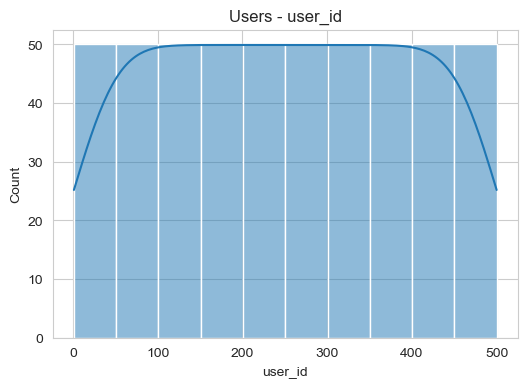

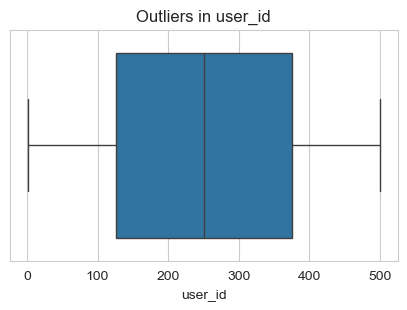

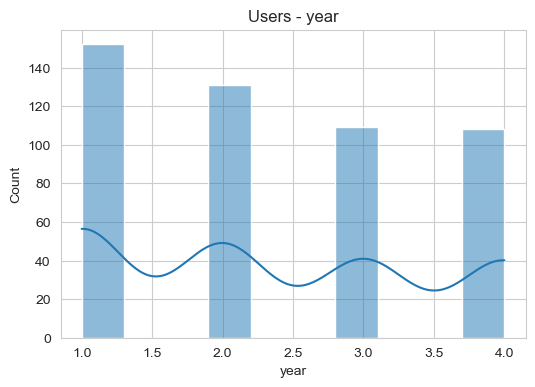

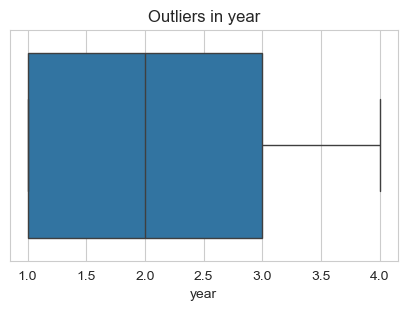

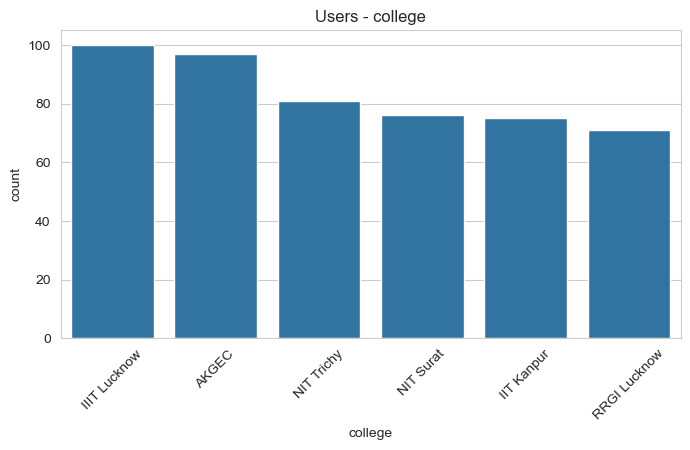

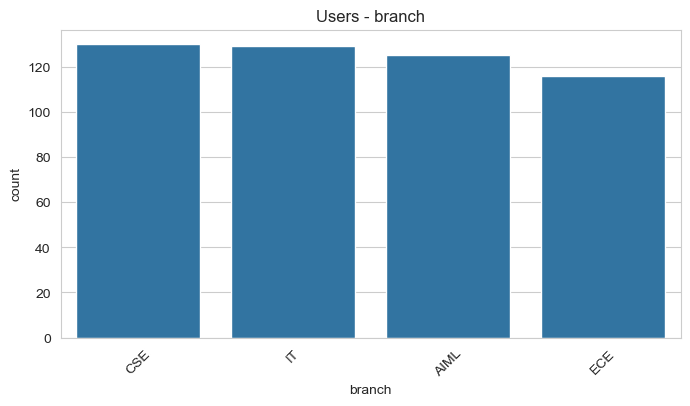

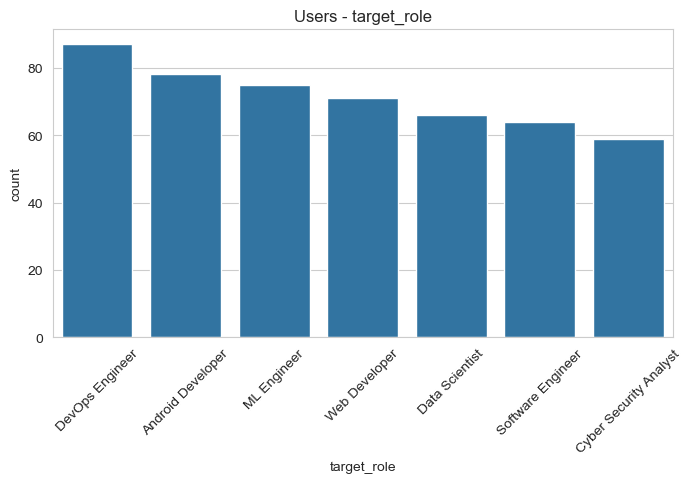

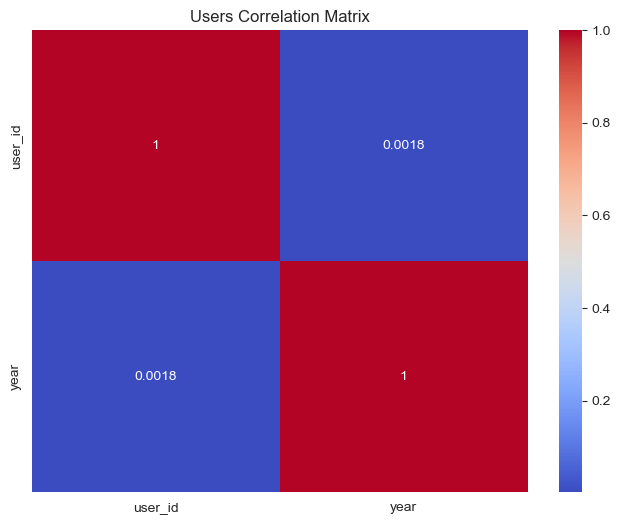

EDA OF SKILLS

First Five Rows

   skill_id  skill_name     category
0         1      Python  Programming
1         2        Java  Programming
2         3         C++  Programming
3         4           C  Programming
4         5  JavaScript  Programming

Shape
(50, 3)

Columns
['skill_id', 'skill_name', 'category']

Data Types
skill_id       int64
skill_name    object
category      object
dtype: object

Missing Values
skill_id      0
skill_name    0
category      0
dtype: int64

Duplicate Rows
0

Unique Values
skill_id      50
skill_name    50
category      15
dtype: int64

Statistical Summary
        skill_id skill_name category
count   50.00000         50       50
unique       NaN         50       15
top          NaN     Python       AI
freq         NaN          1        7
mean    25.50000        NaN      NaN
std     14.57738        NaN      NaN
min      1.00000        NaN      NaN
25%     13.25000        NaN      NaN
50%     25.50000        NaN      NaN
75%     37.75000        NaN  

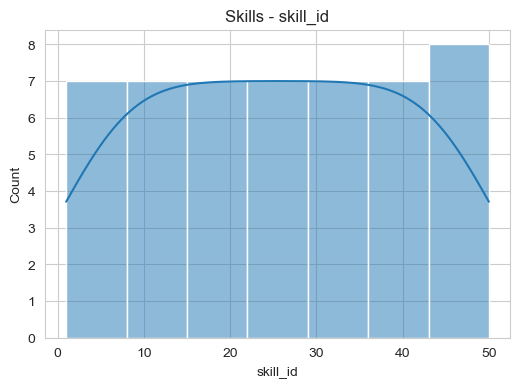

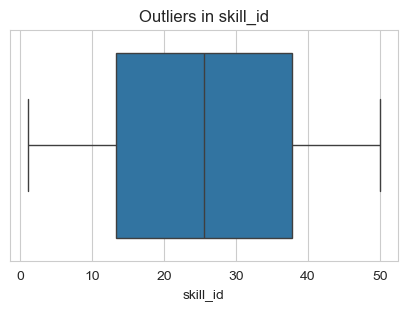

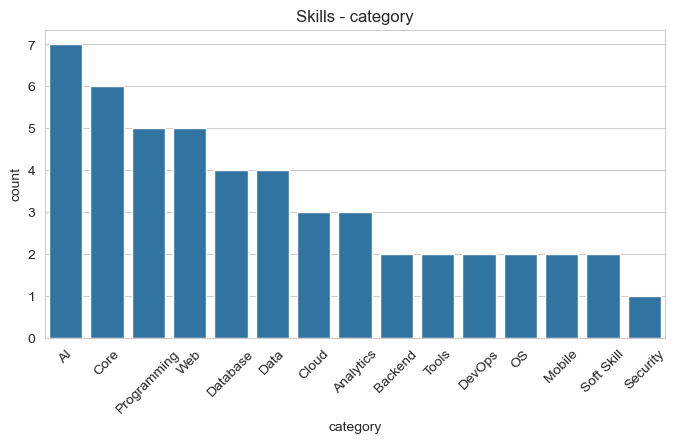

EDA OF USER SKILLS

First Five Rows

   user_id    skill     level
0        1   GitHub  Beginner
1        1   Python  Advanced
2        1  Android  Beginner
3        1    NumPy  Beginner
4        1   Pandas  Beginner

Shape
(3814, 3)

Columns
['user_id', 'skill', 'level']

Data Types
user_id     int64
skill      object
level      object
dtype: object

Missing Values
user_id    0
skill      0
level      0
dtype: int64

Duplicate Rows
0

Unique Values
user_id    500
skill       50
level        3
dtype: int64

Statistical Summary
            user_id   skill     level
count   3814.000000    3814      3814
unique          NaN      50         3
top             NaN  Django  Advanced
freq            NaN      93      1290
mean     252.103041     NaN       NaN
std      143.378978     NaN       NaN
min        1.000000     NaN       NaN
25%      129.000000     NaN       NaN
50%      252.000000     NaN       NaN
75%      377.000000     NaN       NaN
max      500.000000     NaN       NaN


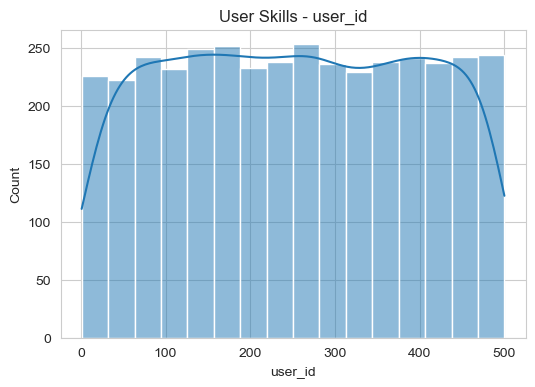

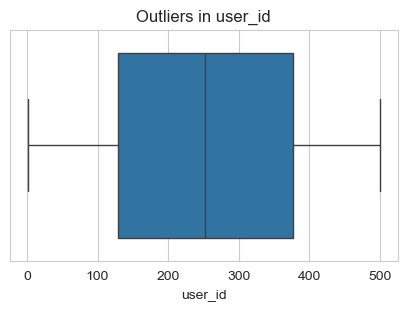

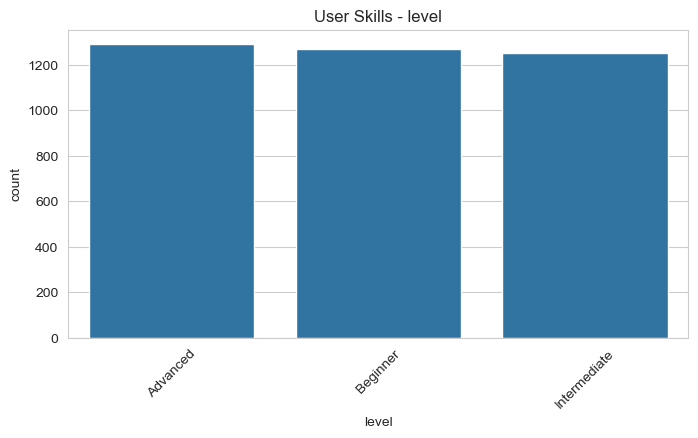

EDA OF CAREER ROLES

First Five Rows

                role required_skill  importance
0  Software Engineer         Python         1.0
1  Software Engineer            DSA         1.0
2  Software Engineer            OOP         0.9
3  Software Engineer           DBMS         0.8
4  Software Engineer            SQL         0.8

Shape
(41, 3)

Columns
['role', 'required_skill', 'importance']

Data Types
role               object
required_skill     object
importance        float64
dtype: object

Missing Values
role              0
required_skill    0
importance        0
dtype: int64

Duplicate Rows
0

Unique Values
role               7
required_skill    33
importance         4
dtype: int64

Statistical Summary
                     role required_skill  importance
count                  41             41   41.000000
unique                  7             33         NaN
top     Software Engineer         Python         NaN
freq                    7              4         NaN
mean                 

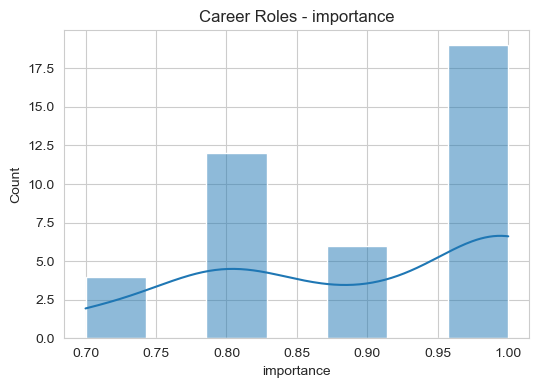

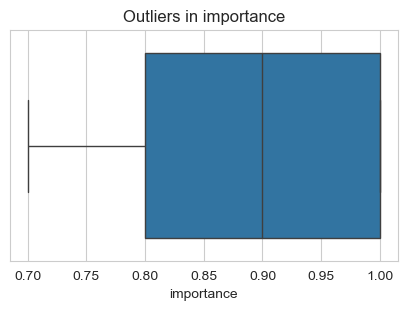

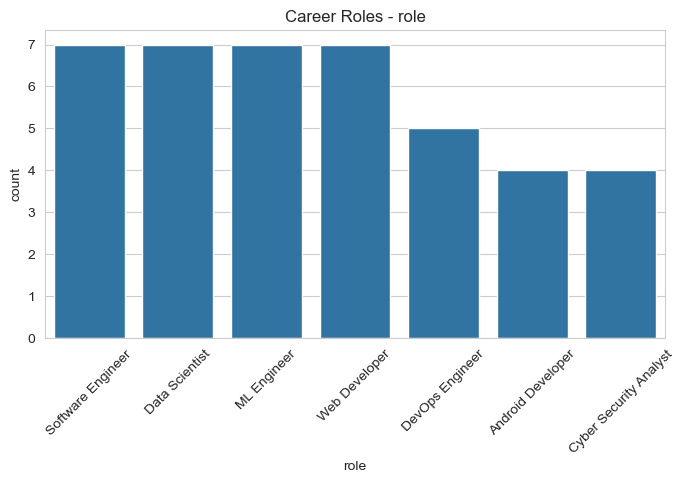

EDA OF LEARNING RESOURCES

First Five Rows

    skill       platform              resource    difficulty
0  Python        YouTube    Python Full Course      Beginner
1  Python  Official Docs  Python Documentation  Intermediate
2    Java        YouTube      Java Full Course      Beginner
3    Java  Official Docs    Java Documentation  Intermediate
4     C++        YouTube       C++ Full Course      Beginner

Shape
(100, 4)

Columns
['skill', 'platform', 'resource', 'difficulty']

Data Types
skill         object
platform      object
resource      object
difficulty    object
dtype: object

Missing Values
skill         0
platform      0
resource      0
difficulty    0
dtype: int64

Duplicate Rows
0

Unique Values
skill          50
platform        2
resource      100
difficulty      2
dtype: int64

Statistical Summary
         skill platform            resource difficulty
count      100      100                 100        100
unique      50        2                 100          2
top     Py

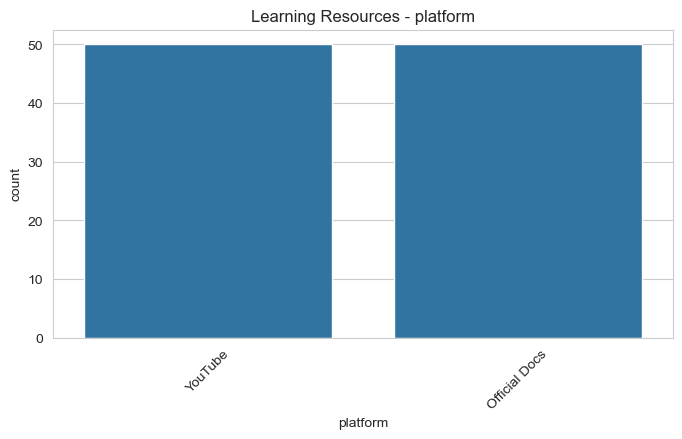

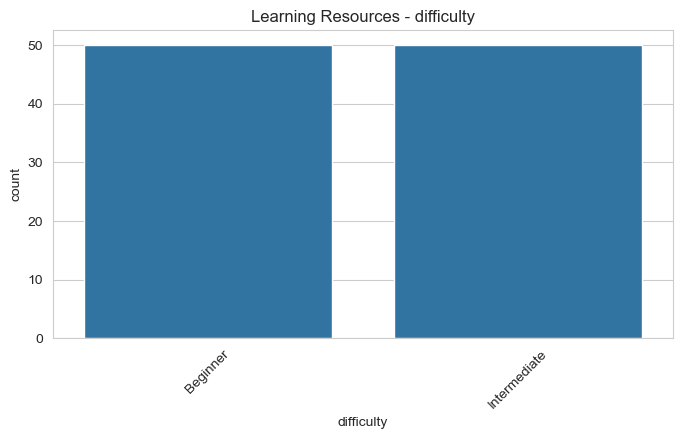

EDA OF PEER DATA

First Five Rows

        college branch  year         skill
0     NIT Surat   AIML     4         MySQL
1    IIT Kanpur    CSE     3        GitHub
2  IIIT Lucknow    ECE     2  Scikit-learn
3  IIIT Lucknow   AIML     4        Pandas
4    NIT Trichy    CSE     3       Node.js

Shape
(1000, 4)

Columns
['college', 'branch', 'year', 'skill']

Data Types
college    object
branch     object
year        int64
skill      object
dtype: object

Missing Values
college    0
branch     0
year       0
skill      0
dtype: int64

Duplicate Rows
90

Unique Values
college     6
branch      4
year        4
skill      50
dtype: int64

Statistical Summary
             college branch         year  skill
count           1000   1000  1000.000000   1000
unique             6      4          NaN     50
top     RRGI Lucknow    ECE          NaN  MySQL
freq             185    257          NaN     31
mean             NaN    NaN     2.465000    NaN
std              NaN    NaN     1.124295    NaN
min

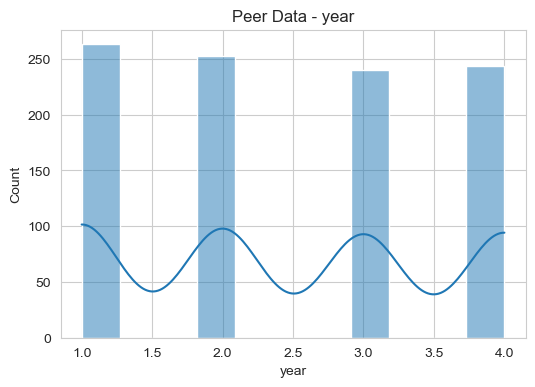

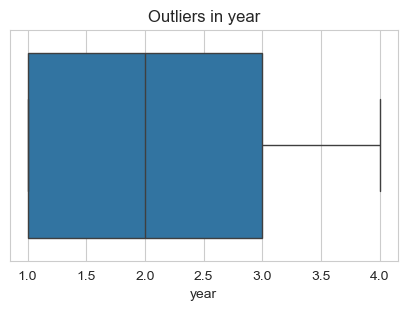

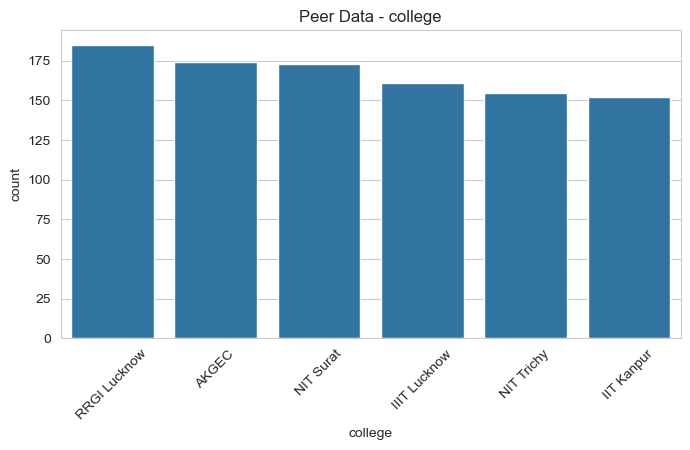

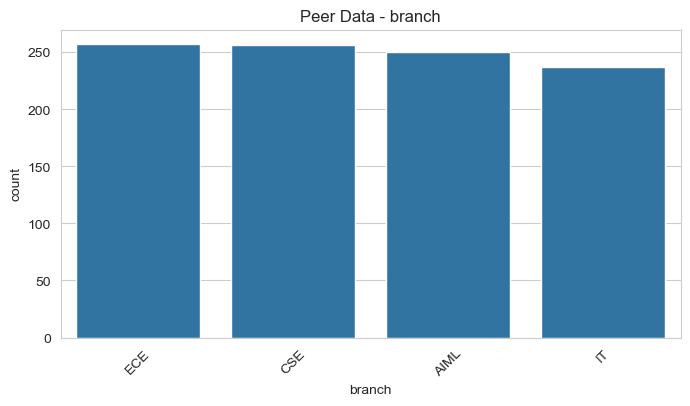


EDA COMPLETED SUCCESSFULLY


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# -----------------------------------
# Load Datasets
# -----------------------------------

datasets = {
    "Users": "Data/users.csv",
    "Skills": "Data/skills.csv",
    "User Skills": "Data/user_skills.csv",
    "Career Roles": "Data/career_roles.csv",
    "Learning Resources": "Data/learning_resources.csv",
    "Peer Data": "Data/peer_data.csv"
}

sns.set_style("whitegrid")

for name, path in datasets.items():

    print("="*80)
    print(f"EDA OF {name.upper()}")
    print("="*80)

    df = pd.read_csv(path)

    # -------------------------------
    # Basic Information
    # -------------------------------

    print("\nFirst Five Rows\n")
    print(df.head())

    print("\nShape")
    print(df.shape)

    print("\nColumns")
    print(df.columns.tolist())

    print("\nData Types")
    print(df.dtypes)

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nDuplicate Rows")
    print(df.duplicated().sum())

    print("\nUnique Values")
    print(df.nunique())

    print("\nStatistical Summary")
    print(df.describe(include="all"))

    # -------------------------------
    # Numerical Columns
    # -------------------------------

    numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

    for col in numeric_cols:

        plt.figure(figsize=(6,4))
        sns.histplot(df[col], kde=True)
        plt.title(f"{name} - {col}")
        plt.show()

        plt.figure(figsize=(5,3))
        sns.boxplot(x=df[col])
        plt.title(f"Outliers in {col}")
        plt.show()

    # -------------------------------
    # Categorical Columns
    # -------------------------------

    cat_cols = df.select_dtypes(include="object").columns

    for col in cat_cols:

        if df[col].nunique() <= 20:

            plt.figure(figsize=(8,4))

            sns.countplot(
                data=df,
                x=col,
                order=df[col].value_counts().index
            )

            plt.xticks(rotation=45)

            plt.title(f"{name} - {col}")

            plt.show()

    # -------------------------------
    # Correlation
    # -------------------------------

    if len(numeric_cols) > 1:

        plt.figure(figsize=(8,6))

        sns.heatmap(
            df[numeric_cols].corr(),
            annot=True,
            cmap="coolwarm"
        )

        plt.title(f"{name} Correlation Matrix")

        plt.show()

print("\nEDA COMPLETED SUCCESSFULLY")

In [8]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
import joblib
import os

# -----------------------------------
# Create Folder
# -----------------------------------
os.makedirs("models", exist_ok=True)
os.makedirs("processed", exist_ok=True)

# -----------------------------------
# Load Data
# -----------------------------------
users = pd.read_csv("processed/users.csv")
skills = pd.read_csv("processed/skills.csv")
user_skills = pd.read_csv("processed/user_skills.csv")
career_roles = pd.read_csv("processed/career_roles.csv")
learning_resources = pd.read_csv("processed/learning_resources.csv")
peer_data = pd.read_csv("processed/peer_data.csv")

print("Datasets Loaded Successfully")

# -----------------------------------
# Label Encoding
# -----------------------------------

label_encoders = {}

categorical_columns = {
    "users": ["college", "branch", "target_role"],
    "career_roles": ["role_name"],
    "learning_resources": ["resource_type"]
}

for col in categorical_columns["users"]:
    le = LabelEncoder()
    users[col] = le.fit_transform(users[col])
    label_encoders[col] = le

if "role_name" in career_roles.columns:
    le = LabelEncoder()
    career_roles["role_name"] = le.fit_transform(career_roles["role_name"])
    label_encoders["role_name"] = le

if "resource_type" in learning_resources.columns:
    le = LabelEncoder()
    learning_resources["resource_type"] = le.fit_transform(
        learning_resources["resource_type"]
    )
    label_encoders["resource_type"] = le

print("Label Encoding Done")

# -----------------------------------
# User Skill Matrix
# -----------------------------------

print("\nCreating User Skill Matrix...")

merged = pd.merge(
    user_skills,
    skills,
    on="skill_id",
    how="left"
)

user_skill_matrix = pd.crosstab(
    merged["user_id"],
    merged["skill_name"]
)

print(user_skill_matrix.head())

# -----------------------------------
# Skill Count
# -----------------------------------

skill_count = merged.groupby("user_id")["skill_id"].count()

users = users.merge(
    skill_count,
    on="user_id",
    how="left"
)

users.rename(
    columns={"skill_id": "total_skills"},
    inplace=True
)

users["total_skills"] = users["total_skills"].fillna(0)

print("Skill Count Feature Added")

# -----------------------------------
# Peer Average Feature
# -----------------------------------

if "score" in peer_data.columns:

    peer_avg = peer_data.groupby("user_id")["score"].mean()

    users = users.merge(
        peer_avg,
        on="user_id",
        how="left"
    )

    users.rename(
        columns={"score": "peer_avg_score"},
        inplace=True
    )

    users["peer_avg_score"] = users["peer_avg_score"].fillna(0)

    print("Peer Score Feature Added")

# -----------------------------------
# Save Engineered Data
# -----------------------------------

users.to_csv(
    "processed/users_featured.csv",
    index=False
)

user_skill_matrix.to_csv(
    "processed/user_skill_matrix.csv"
)

career_roles.to_csv(
    "processed/career_roles_featured.csv",
    index=False
)

learning_resources.to_csv(
    "processed/learning_resources_featured.csv",
    index=False
)

joblib.dump(
    label_encoders,
    "models/label_encoders.pkl"
)

print("\nFeature Engineering Completed Successfully")

print("\nFiles Saved")
print("--------------------------")
print("users_featured.csv")
print("career_roles_featured.csv")
print("learning_resources_featured.csv")
print("user_skill_matrix.csv")
print("label_encoders.pkl")

Datasets Loaded Successfully
Label Encoding Done

Creating User Skill Matrix...


KeyError: 'skill_id'

In [9]:
import pandas as pd

files = [
    "processed/users.csv",
    "processed/skills.csv",
    "processed/user_skills.csv",
    "processed/career_roles.csv",
    "processed/learning_resources.csv",
    "processed/peer_data.csv"
]

for file in files:
    df = pd.read_csv(file)
    print("="*60)
    print(file)
    print(df.columns.tolist())

processed/users.csv
['user_id', 'name', 'college', 'branch', 'year', 'target_role']
processed/skills.csv
['skill_id', 'skill_name', 'category']
processed/user_skills.csv
['user_id', 'skill', 'level']
processed/career_roles.csv
['role', 'required_skill', 'importance']
processed/learning_resources.csv
['skill', 'platform', 'resource', 'difficulty']
processed/peer_data.csv
['college', 'branch', 'year', 'skill']


In [10]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import joblib
import os

# -----------------------------
# Create folders
# -----------------------------
os.makedirs("models", exist_ok=True)
os.makedirs("processed", exist_ok=True)

# -----------------------------
# Load Data
# -----------------------------
users = pd.read_csv("processed/users.csv")
skills = pd.read_csv("processed/skills.csv")
user_skills = pd.read_csv("processed/user_skills.csv")
career_roles = pd.read_csv("processed/career_roles.csv")
learning_resources = pd.read_csv("processed/learning_resources.csv")
peer_data = pd.read_csv("processed/peer_data.csv")

print("Datasets Loaded Successfully")

# ====================================================
# Label Encoding
# ====================================================

label_encoders = {}

user_cols = ["college", "branch", "target_role"]

for col in user_cols:
    le = LabelEncoder()
    users[col] = le.fit_transform(users[col])
    label_encoders[col] = le

# Career Roles
role_encoder = LabelEncoder()
career_roles["role"] = role_encoder.fit_transform(career_roles["role"])
label_encoders["role"] = role_encoder

# Learning Resources
difficulty_encoder = LabelEncoder()
learning_resources["difficulty"] = difficulty_encoder.fit_transform(
    learning_resources["difficulty"]
)
label_encoders["difficulty"] = difficulty_encoder

print("Label Encoding Completed")

# ====================================================
# Total Skills Per User
# ====================================================

skill_count = (
    user_skills.groupby("user_id")
    .size()
    .reset_index(name="total_skills")
)

users = users.merge(skill_count, on="user_id", how="left")
users["total_skills"] = users["total_skills"].fillna(0)

print("Total Skills Feature Added")

# ====================================================
# User Skill Matrix
# ====================================================

print("Creating User Skill Matrix...")

user_skill_matrix = pd.crosstab(
    user_skills["user_id"],
    user_skills["skill"]
)

print(user_skill_matrix.head())

# ====================================================
# Career Mapping Feature
# ====================================================

career_skill_count = (
    career_roles.groupby("role")
    .size()
    .reset_index(name="required_skill_count")
)

career_roles = career_roles.merge(
    career_skill_count,
    on="role",
    how="left"
)

print("Career Features Added")

# ====================================================
# Learning Resource Count
# ====================================================

resource_count = (
    learning_resources.groupby("skill")
    .size()
    .reset_index(name="resource_count")
)

print("Learning Resource Features Added")

# ====================================================
# Peer Skill Frequency
# ====================================================

peer_skill_frequency = (
    peer_data.groupby("skill")
    .size()
    .reset_index(name="peer_frequency")
)

print("Peer Skill Frequency Added")

# ====================================================
# Save Files
# ====================================================

users.to_csv("processed/users_featured.csv", index=False)

user_skill_matrix.to_csv(
    "processed/user_skill_matrix.csv"
)

career_roles.to_csv(
    "processed/career_roles_featured.csv",
    index=False
)

learning_resources.to_csv(
    "processed/learning_resources_featured.csv",
    index=False
)

peer_skill_frequency.to_csv(
    "processed/peer_skill_frequency.csv",
    index=False
)

resource_count.to_csv(
    "processed/resource_count.csv",
    index=False
)

joblib.dump(
    label_encoders,
    "models/label_encoders.pkl"
)

print("\nFeature Engineering Completed Successfully")

print("\nGenerated Files")
print("--------------------------------")
print("users_featured.csv")
print("user_skill_matrix.csv")
print("career_roles_featured.csv")
print("learning_resources_featured.csv")
print("peer_skill_frequency.csv")
print("resource_count.csv")
print("label_encoders.pkl")

Datasets Loaded Successfully
Label Encoding Completed
Total Skills Feature Added
Creating User Skill Matrix...
skill    AWS  Android  Azure  Bash  C  C++  CSS  Communication  \
user_id                                                          
1          0        1      0     0  0    0    0              0   
2          0        0      0     0  0    0    1              0   
3          0        1      0     0  0    0    0              0   
4          0        1      1     0  0    0    0              1   
5          0        0      1     0  0    0    0              0   

skill    Computer Networks  Computer Vision  ...  Power BI  Problem Solving  \
user_id                                      ...                              
1                        0                1  ...         0                0   
2                        0                0  ...         0                0   
3                        0                1  ...         0                0   
4                        0     

In [11]:
import pandas as pd

# -----------------------------
# Load Datasets
# -----------------------------
career = pd.read_csv("processed/career_roles.csv")
resources = pd.read_csv("processed/learning_resources.csv")

print("Datasets Loaded Successfully")

# -----------------------------
# User Input
# -----------------------------
skills = input("Enter your skills (comma separated): ")

user_skills = [
    s.strip().lower()
    for s in skills.split(",")
]

# -----------------------------
# Career Recommendation
# -----------------------------
career["required_skill"] = career["required_skill"].str.lower()

recommended_roles = []

for role in career["role"].unique():

    req = career[career["role"] == role]["required_skill"].tolist()

    matched = len(set(user_skills) & set(req))

    score = matched / len(req)

    if matched > 0:
        recommended_roles.append((role, score, req))

recommended_roles.sort(key=lambda x: x[1], reverse=True)

print("\n==============================")
print("Recommended Careers")
print("==============================")

for role, score, req in recommended_roles[:5]:

    print(f"\nRole : {role}")
    print(f"Match Score : {round(score*100,2)} %")

    missing = list(set(req) - set(user_skills))

    print("Missing Skills :", ", ".join(missing))

# -----------------------------
# Learning Resources
# -----------------------------

print("\n==============================")
print("Learning Resources")
print("==============================")

for role, score, req in recommended_roles[:5]:

    missing = list(set(req) - set(user_skills))

    for skill in missing:

        print(f"\nSkill : {skill}")

        rec = resources[
            resources["skill"].str.lower() == skill
        ]

        if len(rec) == 0:
            print("No Resource Available")
            continue

        for _, row in rec.iterrows():

            print(
                f"{row['platform']} | "
                f"{row['resource']} | "
                f"{row['difficulty']}"
            )

print("\nRecommendation Completed")

Datasets Loaded Successfully

Recommended Careers

Role : Software Engineer
Match Score : 28.57 %
Missing Skills : dbms, system design, git, oop, dsa

Role : Data Scientist
Match Score : 28.57 %
Missing Skills : power bi, scikit-learn, machine learning, numpy, pandas

Role : Cyber Security Analyst
Match Score : 25.0 %
Missing Skills : linux, cyber security, computer networks

Role : ML Engineer
Match Score : 14.29 %
Missing Skills : deep learning, machine learning, tensorflow, pytorch, nlp, computer vision

Learning Resources

Skill : dbms
YouTube | DBMS Full Course | Beginner
Official Docs | DBMS Documentation | Intermediate

Skill : system design
YouTube | System Design Full Course | Beginner
Official Docs | System Design Documentation | Intermediate

Skill : git
YouTube | Git Full Course | Beginner
Official Docs | Git Documentation | Intermediate

Skill : oop
YouTube | OOP Full Course | Beginner
Official Docs | OOP Documentation | Intermediate

Skill : dsa
YouTube | DSA Full Course 